# Assignment 4 — Dataset 1: Diabetes 130-US Hospitals (tabular)

**One learning problem, three implementations: NumPy from scratch, TensorFlow/Keras, and PyTorch.**

This notebook covers the first of the three datasets required by the assignment:

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| **1** | **Diabetes 130-US hospitals** | tabular, 179 features | **MLP** |
| 2 | MNIST | image, 1×28×28 | CNN |
| 3 | CIFAR-10 | image, 3×32×32 | CNN |

### Why an MLP and not a CNN here

Lecture 04, slide 4 makes the distinction that motivates the whole assignment. A tabular row

$$x = [x_1, x_2, \dots, x_d]$$

has no meaningful two-dimensional neighbourhood: feature $x_i$ is not spatially adjacent to $x_{i+1}$ the way
neighbouring pixels are. Convolution exists to exploit *local spatial structure*; where there is none, its two
defining ideas — local connectivity and weight sharing — buy nothing. So:

$$\textbf{Diabetes} \rightarrow \text{MLP} \qquad\qquad \textbf{MNIST / CIFAR-10} \rightarrow \text{CNN}$$

**The model should match the structure of the data.** That sentence is the reason this dataset is in the
assignment at all: it is the control case that shows a CNN is a choice, not a default.

### What stays constant across the three implementations

Slide 29 sets the fairness rule:

> Same Dataset **+** Same Split **+** Same Architecture **+** Comparable Hyperparameters

All three legs below pull their arrays from the same `ass4_utils` loader with the same seed, so they see
byte-identical training and test sets. Only the *level of abstraction* changes.

In [1]:
import os, sys, json, time, platform

# TensorFlow is CPU-only on Windows (no GPU support since 2.10); silence its startup chatter.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import tensorflow as tf
import keras

print("python     ", platform.python_version())
print("numpy      ", np.__version__)
print("torch      ", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow ", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")
print("keras      ", keras.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

python      3.11.8
numpy       2.2.6
torch       2.10.0+cu130 | CUDA: True | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow  2.21.0 | GPUs: none (CPU)
keras       3.15.1


---
## 1. The data

The dataset is the UCI *Diabetes 130-US hospitals for years 1999–2008* release: ten years of inpatient
records, **101,766 encounters × 50 columns**. It is downloaded automatically on first run.

The loader in `ass4_utils.py` applies the preprocessing that is standard for this dataset:

1. **One row per patient.** Repeat encounters of the same patient leak the outcome of earlier admissions
   into later ones, so only the first admission is kept.
2. **Drop expired/hospice discharges.** Those patients cannot be readmitted; scoring them as `NO` would
   teach the model a false pattern.
3. **Drop identifiers and near-empty columns** — `weight` (96.9 % missing), `payer_code` (39.6 %),
   `medical_specialty` (49.1 %), plus the two constant drug columns `examide` and `citoglipton`.
4. **Group the ICD-9 diagnosis codes.** `diag_1..3` hold ~700 distinct codes each; they are collapsed into
   nine clinical groups (circulatory, respiratory, diabetes, …) so one-hot encoding stays tractable.
5. **One-hot the categoricals, standardise the numerics** using *training* statistics only.

The target is `readmitted` with three classes: `NO`, `>30` days, `<30` days.

In [2]:
X_train, y_train, X_test, y_test, meta = U.load_diabetes130()

N_FEATURES = X_train.shape[1]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ntrain {X_train.shape}   test {X_test.shape}   dtype {X_train.dtype}")
print(f"features: {N_FEATURES}   classes: {CLASSES}")

Diabetes 130-US hospitals: raw (101766, 50) -> (69973, 179), train 55979 / test 13994, 179 features, 3 classes

train (55979, 179)   test (13994, 179)   dtype float32
features: 179   classes: ['NO', '>30', '<30']


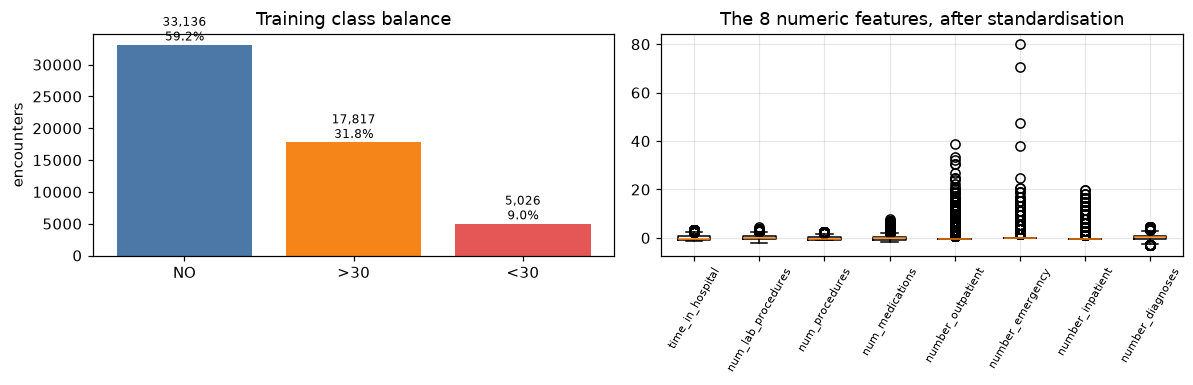

class      train    share
NO        33,136    59.2%
>30       17,817    31.8%
<30        5,026     9.0%


In [3]:
# Class balance and a look at the feature block structure.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

counts = np.bincount(y_train, minlength=N_CLASSES)
bars = ax[0].bar(CLASSES, counts, color=["#4C78A8", "#F58518", "#E45756"])
ax[0].set_title("Training class balance")
ax[0].set_ylabel("encounters")
for b, c in zip(bars, counts):
    ax[0].text(b.get_x() + b.get_width() / 2, c, f"{c:,}\n{c/counts.sum():.1%}",
               ha="center", va="bottom", fontsize=8)

numeric_names = [n for n in meta["feature_names"][:8]]
ax[1].boxplot([X_train[:, i] for i in range(8)], tick_labels=numeric_names)
ax[1].set_title("The 8 numeric features, after standardisation")
ax[1].tick_params(axis="x", rotation=60, labelsize=7)
ax[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"{'class':<6}{'train':>10}{'share':>9}")
for i, c in enumerate(CLASSES):
    print(f"{c:<6}{counts[i]:>10,}{counts[i]/counts.sum():>9.1%}")

> **The imbalance matters for how we read the results later.** Predicting `NO` for every single patient
> already scores ~59 % accuracy while being clinically useless. That is why the comparison tables report
> **macro F1** alongside accuracy: macro F1 averages over the three classes equally, so a model that
> ignores the rare `<30` class cannot hide behind the majority class.

---
## 2. The shared architecture

Every implementation below builds *this* function, and nothing else:

$$X \;\rightarrow\; \text{Linear}_{179\rightarrow128} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{Dropout}_{0.3}
\;\rightarrow\; \text{Linear}_{128\rightarrow64} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{Linear}_{64\rightarrow3} \;\rightarrow\; \hat{y}$$

which is the tutorial's central claim made concrete — a network *is* a composition of functions:

$$F = f_5 \circ f_4 \circ f_3 \circ f_2 \circ f_1$$

### Counting the parameters by hand first

Tutorial §43 gives the rule for a linear layer:

$$N_{\text{params}} = N_{\text{in}} N_{\text{out}} + N_{\text{out}}$$

Doing the arithmetic *before* asking any framework is the point of the exercise — each implementation is then
checked against this number, and all three must agree.

In [4]:
HIDDEN1, HIDDEN2, DROPOUT = 128, 64, 0.3
EPOCHS, BATCH_SIZE, LR = 15, 256, 1e-3

# Hand-computed, per tutorial section 43: N_in * N_out + N_out
manual = [
    ("Linear 179->128", N_FEATURES * HIDDEN1 + HIDDEN1),
    ("ReLU",            0),
    ("Dropout 0.3",     0),
    ("Linear 128->64",  HIDDEN1 * HIDDEN2 + HIDDEN2),
    ("ReLU",            0),
    ("Linear 64->3",    HIDDEN2 * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"{'layer':<20}{'params':>10}")
print("-" * 30)
for name, p in manual:
    print(f"{name:<20}{p:>10,}")
print("-" * 30)
print(f"{'TOTAL (by hand)':<20}{EXPECTED_PARAMS:>10,}")
print(f"\nshared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

results = []   # collects one U.RunResult per implementation

layer                   params
------------------------------
Linear 179->128         23,040
ReLU                         0
Dropout 0.3                  0
Linear 128->64           8,256
ReLU                         0
Linear 64->3               195
------------------------------
TOTAL (by hand)         31,491

shared hyperparameters: epochs=15, batch_size=256, optimizer=Adam(lr=0.001)


---
## 3. Implementation A — from scratch (NumPy)

No framework. `scratch_nn.py` defines each layer as an explicit function with a hand-derived gradient, and
the training loop spells out all four steps of the cycle:

$$\text{Forward} \;\rightarrow\; \text{Loss} \;\rightarrow\; \text{Gradient} \;\rightarrow\; \text{Update}$$

Adam is written out as arithmetic rather than called from a library, so nothing about the update rule is hidden.

In [5]:
U.set_seed(U.SEED)

scratch_model = S.Sequential([
    S.Dense(N_FEATURES, HIDDEN1, seed=1),
    S.ReLU(),
    S.Dropout(DROPOUT, seed=11),
    S.Dense(HIDDEN1, HIDDEN2, seed=2),
    S.ReLU(),
    S.Dense(HIDDEN2, N_CLASSES, seed=3),
])

print(scratch_model.summary(input_shape=(N_FEATURES,)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? "
      f"{scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Dense(179 -> 128)                     (128,)                    23,040
ReLU                                  (128,)                         0
Dropout(p=0.3)                        (128,)                         0
Dense(128 -> 64)                      (64,)                      8,256
ReLU                                  (64,)                          0
Dense(64 -> 3)                        (3,)                         195
----------------------------------------------------------------------
total                                                           31,491

matches hand count 31,491? True


### Are the hand-written gradients actually right?

Before trusting anything this model reports, the analytic gradients are checked against central finite
differences,

$$\frac{\partial \mathcal{L}}{\partial \theta_i} \;\approx\; \frac{\mathcal{L}(\theta_i + \epsilon) - \mathcal{L}(\theta_i - \epsilon)}{2\epsilon}$$

on a small batch in float64. A relative error below ~1e-4 means the backward pass derived by hand agrees
with the numerical derivative — the framework legs get this correctness for free from autodiff, so the
scratch leg has to earn it.

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Dense(N_FEATURES, 16, seed=1),
    S.ReLU(),
    S.Dense(16, N_CLASSES, seed=3),
])
err = S.gradient_check(check_model, X_train[:8], y_train[:8], n_samples=8)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS — hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL — backward pass disagrees with finite differences")

worst relative error vs finite differences: 4.511e-07
PASS — hand-derived gradients agree with the numerical derivative


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/15  loss 0.9719  0.5s  test_acc 0.6003


epoch 2/15  loss 0.8816  0.5s  test_acc 0.6042


epoch 3/15  loss 0.8646  0.5s  test_acc 0.6045


epoch 4/15  loss 0.8555  0.6s  test_acc 0.6065


epoch 5/15  loss 0.8476  0.6s  test_acc 0.6089


...

epoch 11/15  loss 0.8317  0.5s  test_acc 0.6071


epoch 12/15  loss 0.8292  0.5s  test_acc 0.6100


epoch 13/15  loss 0.8282  0.5s  test_acc 0.6086


epoch 14/15  loss 0.8253  0.6s  test_acc 0.6073


epoch 15/15  loss 0.8237  0.6s  test_acc 0.6094

total training time: 8.5s


In [8]:
pred = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset=meta["name"], model="MLP 179-128-64-3",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.6094   macro-F1 0.3450


---
## 4. Implementation B — TensorFlow / Keras

The same composition, expressed as a list of reusable layers. Compare what disappeared from our code:
the explicit loop over batches, the loss computation, the gradient and the parameter update are all now
inside `fit()`.

> **Note on hardware.** Windows-native TensorFlow has shipped without GPU support since version 2.10, so this
> leg runs on CPU while the PyTorch leg below uses the GPU. Training times are therefore **not** directly
> comparable across those two rows — the parameter counts and accuracies are.

In [9]:
U.set_seed(U.SEED)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(HIDDEN1, activation="relu"),
    keras.layers.Dropout(DROPOUT),
    keras.layers.Dense(HIDDEN2, activation="relu"),
    keras.layers.Dense(N_CLASSES),          # raw logits, like the other two legs
], name="diabetes_mlp")

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? "
      f"{keras_model.count_params() == EXPECTED_PARAMS}")

Model: "diabetes_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,491 (123.01 KB)

 Trainable params: 31,491 (123.01 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 31,491? True


In [10]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/15


219/219 - 2s - 9ms/step - accuracy: 0.5829 - loss: 0.9071 - val_accuracy: 0.6032 - val_loss: 0.8665


Epoch 2/15


219/219 - 1s - 3ms/step - accuracy: 0.5995 - loss: 0.8653 - val_accuracy: 0.6078 - val_loss: 0.8586


Epoch 3/15


...

Epoch 14/15


219/219 - 1s - 4ms/step - accuracy: 0.6222 - loss: 0.8193 - val_accuracy: 0.6074 - val_loss: 0.8542


Epoch 15/15


219/219 - 1s - 4ms/step - accuracy: 0.6249 - loss: 0.8174 - val_accuracy: 0.6077 - val_loss: 0.8549



total training time: 13.8s


In [11]:
pred = keras_model.predict(X_test, batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset=meta["name"], model="MLP 179-128-64-3",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.6077   macro-F1 0.3686


---
## 5. Implementation C — PyTorch

The same composition again, as an `nn.Module`. PyTorch sits between the other two: the *model* is as compact
as Keras, but the *training loop* is as explicit as the scratch version —

$$\text{Zero Gradient} \rightarrow \text{Forward} \rightarrow \text{Loss} \rightarrow \text{Backward} \rightarrow \text{Update}$$

is written out line by line. What PyTorch supplies that the scratch code had to derive by hand is
`loss.backward()`: autograd.

In [12]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

U.set_seed(U.SEED)

class DiabetesMLP(nn.Module):
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, HIDDEN1),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN1, HIDDEN2),
            nn.ReLU(),
            nn.Linear(HIDDEN2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

torch_model = DiabetesMLP(N_FEATURES, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}")
print(f"matches hand count {EXPECTED_PARAMS:,}? {n_torch == EXPECTED_PARAMS}")

DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=179, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=3, bias=True)
  )
)

parameters: 31,491
matches hand count 31,491? True


In [13]:
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

Xte_t = torch.tensor(X_test).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=LR)

hist_torch = {"loss": [], "val_acc": []}

with U.Timer() as t_torch:
    for epoch in range(1, EPOCHS + 1):
        torch_model.train()
        running, nb = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()          # 1. zero gradient
            logits = torch_model(xb)       # 2. forward
            loss = criterion(logits, yb)   # 3. loss
            loss.backward()                # 4. backward  (autograd)
            optimizer.step()               # 5. update

            running += loss.item(); nb += 1

        torch_model.eval()
        with torch.no_grad():
            acc = (torch_model(Xte_t).argmax(1).cpu().numpy() == y_test).mean()

        hist_torch["loss"].append(running / nb)
        hist_torch["val_acc"].append(float(acc))
        print(f"epoch {epoch}/{EPOCHS}  loss {running/nb:.4f}  test_acc {acc:.4f}")

print(f"\ntotal training time: {t_torch.seconds:.1f}s")

epoch 1/15  loss 0.8733  test_acc 0.6093


epoch 2/15  loss 0.8493  test_acc 0.6103


epoch 3/15  loss 0.8421  test_acc 0.6095


epoch 4/15  loss 0.8402  test_acc 0.6083


epoch 5/15  loss 0.8363  test_acc 0.6105


...

epoch 11/15  loss 0.8201  test_acc 0.6110


epoch 12/15  loss 0.8191  test_acc 0.6108


epoch 13/15  loss 0.8161  test_acc 0.6095


epoch 14/15  loss 0.8155  test_acc 0.6121


epoch 15/15  loss 0.8135  test_acc 0.6105

total training time: 19.3s


In [14]:
torch_model.eval()
with torch.no_grad():
    pred = torch_model(Xte_t).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset=meta["name"], model="MLP 179-128-64-3",
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(t_torch.seconds, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.6105   macro-F1 0.3694


---
## 6. Comparison

### 6.1 The numbers slide 29 asks for

In [15]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,8.48,0.8237,0.6094,0.4798,0.3728,0.3450
1,TensorFlow/Keras,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,13.79,0.8174,0.6077,0.4839,0.3842,0.3686
2,PyTorch,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,19.32,0.8135,0.6105,0.5129,0.3860,0.3694


In [16]:
# A majority-class baseline, so the accuracies above can be read honestly.
majority = np.bincount(y_train).argmax()
base = U.evaluate(y_test, np.full_like(y_test, majority), N_CLASSES)
print(f"always-predict-'{CLASSES[majority]}' baseline: "
      f"accuracy {base['test_accuracy']:.4f}   macro-F1 {base['f1_macro']:.4f}")
print(f"best model:                   "
      f"accuracy {table['test_accuracy'].max():.4f}   macro-F1 {table['f1_macro'].max():.4f}")

always-predict-'NO' baseline: accuracy 0.5958   macro-F1 0.2489
best model:                   accuracy 0.6105   macro-F1 0.3694


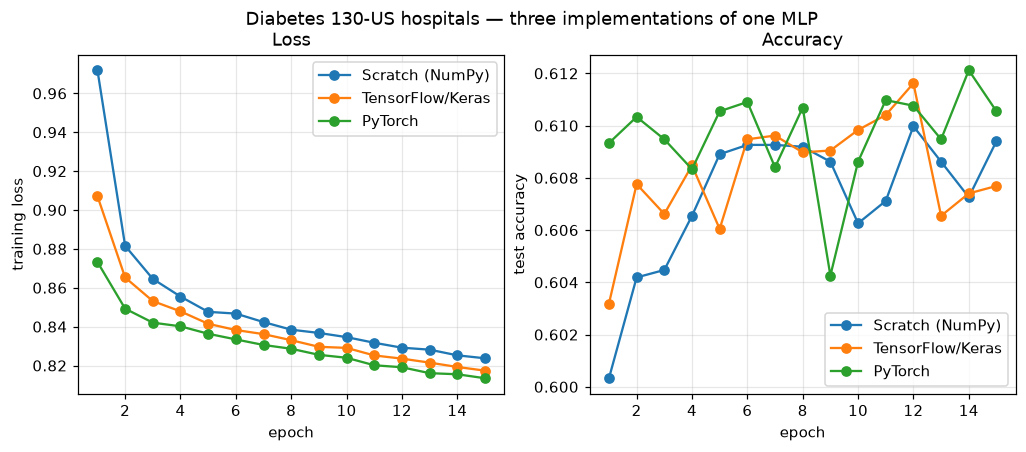

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title=f"{meta['name']} — three implementations of one MLP")
plt.show()

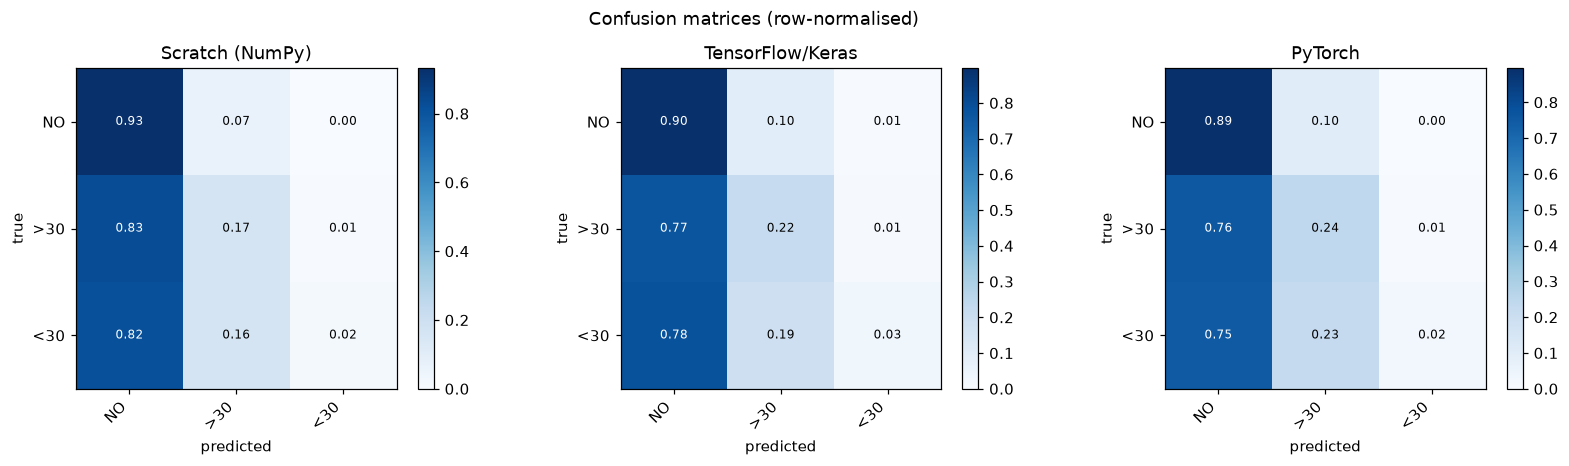

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout()
plt.show()

### 6.2 Where each component lives

This is the table slide 28 asks students to submit, filled in for this notebook.

In [19]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy arrays", "same arrays",              "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",        "shared",                   "shared"],
    ["Model definition","S.Sequential([...])",        "keras.Sequential([...])",  "nn.Module + nn.Sequential"],
    ["Dense layer",     "S.Dense (x@W+b by hand)",    "keras.layers.Dense",       "nn.Linear"],
    ["Activation",      "S.ReLU (mask multiply)",     "activation='relu'",        "nn.ReLU"],
    ["Regularisation",  "S.Dropout (inverted)",       "keras.layers.Dropout",     "nn.Dropout"],
    ["Loss",            "S.SoftmaxCrossEntropy",      "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward()",    "automatic (GradientTape)", "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",       "keras.optimizers.Adam",    "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",          "model.fit()",              "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",  "predict + sklearn",        "forward + sklearn"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,ass4_utils -> NumPy arrays,same arrays,same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module + nn.Sequential
3,Dense layer,S.Dense (x@W+b by hand),keras.layers.Dense,nn.Linear
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,Regularisation,S.Dropout (inverted),keras.layers.Dropout,nn.Dropout
6,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
7,Gradient,hand-derived backward(),automatic (GradientTape),automatic (autograd)
8,Optimizer,S.Adam (written out),keras.optimizers.Adam,torch.optim.Adam
9,Training loop,explicit for-loop,model.fit(),explicit for-loop


In [20]:
# Persist for 04_compare.ipynb
os.makedirs("results", exist_ok=True)
with open("results/01_diabetes130.json", "w") as f:
    json.dump({"meta": {k: v for k, v in meta.items() if k != "feature_names"},
               "results": [r.__dict__ for r in results],
               "component_table": component_table.to_dict(orient="records")},
              f, indent=2, default=str)
print("saved results/01_diabetes130.json")

saved results/01_diabetes130.json


---
## 7. What this dataset shows

**The three implementations agree.** All three build the same 31,491-parameter function, and all three land
within noise of each other on accuracy and macro F1. Different names — `S.Dense`, `keras.layers.Dense`,
`nn.Linear` — do not imply different machine-learning concepts. The abstraction level changed; the mathematics
did not.

**Accuracy is the wrong headline here.** With a 59 / 32 / 9 class split, the always-predict-`NO` baseline is
already close to what the trained networks reach. The macro F1 column is what separates a model that learned
something from one that learned the prior. Hospital readmission is genuinely hard to predict from
administrative fields — the published literature on this dataset reports AUCs around 0.65, and nothing here
contradicts that.

**The tabular case is the control.** No convolution appears anywhere in this notebook, because there is no
spatial neighbourhood for a kernel to exploit. That is what makes the next two notebooks meaningful: when
MNIST and CIFAR-10 introduce `Conv2D`, it will be a response to a property the data actually has, not a
default choice.

**The GPU did not help here — and that is worth pausing on.** On this dataset the PyTorch leg is the *slowest*
of the three despite running on an RTX 3060, while the hand-written NumPy leg is the fastest. The model is
tiny and the data is tabular, so each batch carries too little arithmetic to amortise the cost of moving it to
the device and back; the transfer overhead dominates. Hardware acceleration is not free, and it is not
automatic. The two image notebooks provide exactly the condition it needs — enough work per batch to pay for
itself — and there the ordering reverses sharply.

**What the scratch leg bought.** It is the only one whose gradients had to be proved correct rather than
inherited from autodiff. In exchange, every quantity in the training cycle is visible — and the
finite-difference check above is the evidence that "visible" also means "right".

Next: **`02_mnist.ipynb`**, where the data has spatial structure and the architecture changes to match it.